# Teachable machine

Intussen heb je de teachable machine van Google al eens uitgeprobeerd. In deze notebook gaan we dieper in op de werking van deze teachable machine. Je zal leren hoe je een bestaand AI-model kan aanpassen zodat het werkt voor de data die jij hebt. Deze techniek wordt meestal **transfer learning** genoemd. 

## Transfer learning

Bij transfer learning starten we van een bestaand AI-model. Dit model passen we aan voor onze taak. Hier baseren we ons op het ImageNet model. Dit model werd getraind met meer dan een miljoen afbeeldingen van 1000 verschillende objecten. Het is dus al zeer goed in het detecteren van deze objecten. In deze notebook voeg je een laag toe aan ImageNet en train je die laag om papier en PMD te herkennen.

Voor we kunnen starten, importeren we de nodige bibliotheken. De keras bibliotheek bevat al heel wat functies die het ons gemakkelijke maken om een neuraal netwerk te trainen. Ook de tensorflow bibliotheek is specifiek ontworpen om gemakkelijke neurale netwerken te kunnen bouwen.

In [14]:
import keras
import tensorflow as tf
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split

ModuleNotFoundError: No module named 'sklearn'

## ImageNet inladen

We laden eerst en vooral het bestaande AI-model in. Dit model passen we verder in de notebook aan.

In [2]:
imageNet = keras.applications.MobileNetV2(
    weights="imagenet",
)

We kunnen de structuur van het ImageNet netwerk bekijken met het volgende commando.

In [3]:
print(imageNet.summary())

Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 3,538,984 (13.50 MB)

 Trainable params: 3,504,872 (13.37 MB)

 Non-trainable params: 34,112 (133.25 KB)

None


Je ziet dat het model 3 504 872 *Trainable params* ofwel trainbare parameters heeft. Dit zijn de gewichten van het netwerk die aangepast worden tijdens het trainingsproces.

In de tabel die weergegeven wordt, zie je heel wat rijen. Elke rij komt overeen met een laag in het neurale netwerk. Met het volgende commando kan je tellen hoeveel lagen het netwerk heeft.

In [6]:
print(len(imageNet.layers))

156


# Een dataset opstellen

Voor we het model kunnen aanpassen aan ons probleem, hebben we een dataset nodig. Deze dataset zal afbeeldingen van papier en PMD bevatten. In de bestandsverkenner aan de linker kant zie je een mapje *dataset* daarin vind je twee submapjes: *papier* en *PMD*. Deze mapjes bevatten de afbeeldingen waarop we gaan trainen.

In de volgende codecel laden we de afbeeldingen in elk mapje in in een lijst.

In [8]:
# Leg vast hoe de afbeeldingen eruit zien
batch_size = 16
img_hoogte = 224
img_breedte = 224

# gebruik de Keras functie image_dataset_from_directory om de data in te laden
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "dataset",
    image_size=(img_hoogte, img_breedte),
    batch_size=batch_size,
    label_mode='binary'
)

Found 90 files belonging to 2 classes.


In [ ]:
# print information about the dataset
print(dataset.class_names)
print(dataset.file_paths)

# split the dataset into a training, test and validation sets
train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = int(0.15 * len(dataset))

train_dataset = dataset.take(train_size)
test_dataset = dataset.skip(train_size)
val_dataset = test_dataset.skip(test_size)





['papier', 'pmd']
['dataset\\pmd\\pmd_20.jpg', 'dataset\\pmd\\pmd_28.jpg', 'dataset\\papier\\papier_20.jpg', 'dataset\\papier\\papier_5.jpg', 'dataset\\pmd\\pmd_35.jpg', 'dataset\\papier\\papier_3.jpg', 'dataset\\pmd\\pmd_41.jpg', 'dataset\\pmd\\pmd_34.jpg', 'dataset\\papier\\papier_26.jpg', 'dataset\\papier\\papier_22.jpg', 'dataset\\papier\\papier_6.jpg', 'dataset\\papier\\papier_29.jpg', 'dataset\\papier\\papier_44.jpg', 'dataset\\papier\\papier_12.jpg', 'dataset\\papier\\papier_19.jpg', 'dataset\\papier\\papier_27.jpg', 'dataset\\pmd\\pmd_9.jpg', 'dataset\\papier\\papier_18.jpg', 'dataset\\papier\\papier_30.jpg', 'dataset\\papier\\papier_14.jpg', 'dataset\\pmd\\pmd_21.jpg', 'dataset\\papier\\papier_31.jpg', 'dataset\\papier\\papier_45.jpg', 'dataset\\papier\\papier_8.jpg', 'dataset\\pmd\\pmd_38.jpg', 'dataset\\papier\\papier_7.jpg', 'dataset\\papier\\papier_37.jpg', 'dataset\\pmd\\pmd_24.jpg', 'dataset\\papier\\papier_32.jpg', 'dataset\\pmd\\pmd_1.jpg', 'dataset\\papier\\papier_1.j

AttributeError: 'str' object has no attribute 'numpy'

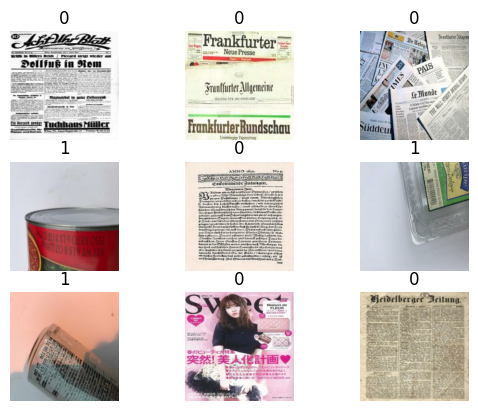

In [10]:
# View the first image in the dataset
import matplotlib.pyplot as plt

for images, labels in dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(int(labels[i]))
        plt.axis("off")
        
plt.show()
